# 📊 Return Probability Prediction + Rule-Based Action Engine

This notebook builds a predictive model designed to score e-commerce orders on their **probability of return**. 

Instead of making binary Yes/No classifications, the ML model produces a **Return Risk Score (0 to 1)**. This prediction is fed into a **Rule-Based Decision Layer** that dictates the ultimate business interaction (e.g., block COD, restrict shipment speed, alert the customer) based not only on probability but also on customer behavior traits.

---
## 1. 🧾 Problem Statement

* **Objective:** Predict the **continuous probability of a product being returned**, rather than a strict binary classification.
* **Business Impact:** 
  * Reduce logistics and reverse-shipping losses.
  * Optimize inventory visibility.
  * Improve customer satisfaction via targeted friction limits.
* **Architecture:** 
  > **Note:** The model does NOT take autonomous decisions — it only evaluates risk. The **Decision Engine (Rule-Based System)** dictates the final downstream actions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

## 2. 📂 Dataset Selection

We are using our synthetic multi-domain e-commerce dataset generated to accurately simulate supply chain logistics, customer profiles, and product characteristics.

In [2]:
# Load the dataset
# Adjusting path to point to the 'data/' directory generated earlier
data_path = '../data/final_combined_data.csv'
df = pd.read_csv(data_path)

print(f"Dataset successfully loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset successfully loaded with 3000 rows and 51 columns.


## 3. 📊 Dataset Description & 4. 📘 Data Documentation

The dataset merges `products`, `customers`, `orders`, `logistics`, and `returns`.
* **Input Features:** Include multi-domain data covering delivery timings, pricing, category rates, and historical return rates.
* **Target Feature:** We will use `is_returned` as the ground truth. Since we are using a **Regression** model on a binary target, the output naturally models the **`return_probability`** in the range [0.0, 1.0].

In [3]:
# Display primary column info
display(df.info())

# Preview top features
display(df[['is_returned', 'delivery_delay', 'discount_percentage', 'avg_rating', 'overall_return_rate', 'frequent_return_flag']].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    3000 non-null   object 
 1   customer_id                 3000 non-null   object 
 2   product_id                  3000 non-null   object 
 3   order_date                  3000 non-null   object 
 4   order_day_of_week           3000 non-null   object 
 5   order_hour                  3000 non-null   int64  
 6   quantity                    3000 non-null   int64  
 7   product_price               3000 non-null   int64  
 8   discount_amount             3000 non-null   float64
 9   discount_percentage         3000 non-null   int64  
 10  final_price                 3000 non-null   float64
 11  payment_method              3000 non-null   object 
 12  is_cod                      3000 non-null   int64  
 13  shipping_mode               3000 

None

,is_returned,delivery_delay,discount_percentage,avg_rating,overall_return_rate,frequent_return_flag
0,0,0,10,4.8,0.16,0
1,1,2,12,4.2,0.00,0
2,1,3,40,3.9,0.00,0
3,0,0,19,4.5,0.00,0
4,0,0,10,4.3,0.00,0


## 5. 📥 Raw Data Exploration

Let's look at the basic statistical distribution of our underlying numeric features and the baseline layout of returns.

,order_hour,quantity,product_price,discount_amount,discount_percentage,final_price,is_cod,expected_delivery_days,actual_delivery_days,delivery_delay,...,avg_days_between_orders,last_order_days_ago,frequent_return_flag,price,product_return_rate,category_return_rate,avg_rating,rating_variance,size_variants_count,is_fragile
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,11.598000,1.207667,14360.001000,3021.929857,17.441000,14072.557477,0.417667,3.289000,4.074667,0.785667,...,17.497593,32.000000,0.108000,14360.001000,0.130257,0.130662,4.290167,0.512800,3.642667,0.506333
std,6.989135,0.514421,13920.551064,4746.121845,12.878243,15951.337149,0.493257,1.763287,2.240855,1.247763,...,7.276906,16.468852,0.310432,13920.551064,0.076203,0.075275,0.306656,0.255769,2.815248,0.500043
min,0.000000,1.000000,1799.000000,0.000000,0.000000,1043.420000,0.000000,0.000000,0.000000,0.000000,...,5.013573,1.000000,0.000000,1799.000000,0.050000,0.065000,3.900000,0.200000,1.000000,0.000000
25%,5.000000,1.000000,3199.000000,247.420000,9.000000,2559.200000,0.000000,2.000000,2.000000,0.000000,...,11.130783,19.000000,0.000000,3199.000000,0.070000,0.065000,4.000000,0.300000,1.000000,0.000000
50%,12.000000,1.000000,11999.000000,979.720000,20.000000,8279.310000,0.000000,3.000000,4.000000,0.000000,...,17.256721,32.500000,0.000000,11999.000000,0.080000,0.070000,4.300000,0.400000,1.000000,1.000000
75%,18.000000,1.000000,24990.000000,3999.900000,30.000000,22491.000000,1.000000,5.000000,6.000000,1.000000,...,23.933763,46.000000,0.000000,24990.000000,0.220000,0.235000,4.500000,0.800000,6.000000,1.000000
max,23.000000,3.000000,39999.000000,50398.740000,42.000000,119997.000000,1.000000,6.000000,13.000000,7.000000,...,29.981047,60.000000,1.000000,39999.000000,0.250000,0.235000,4.800000,0.900000,8.000000,1.000000


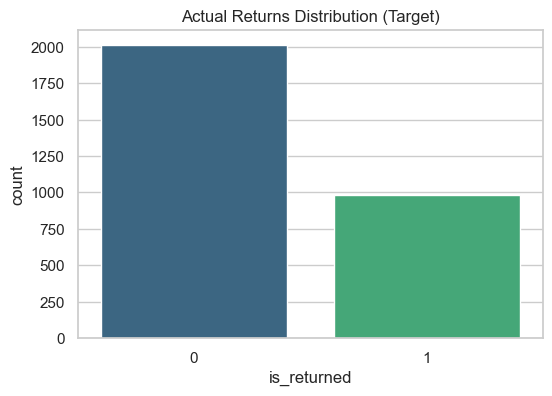

In [4]:
# Descriptive statistics
display(df.describe())

# Visualizing baseline return classes to understand the base probability
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_returned', palette='viridis')
plt.title('Actual Returns Distribution (Target)')
plt.show()

## 6. 🧹 Data Cleaning & 7. 📉 Outlier Analysis

Because we utilize an actively maintained synthetic generator, there are no missing values. However, we'll strip out non-predictive baseline IDs to avoid overfitting or dimensionality problems. Furthermore, we cap extreme delays effectively.

In [5]:
# Sort by order_date to enforce Temporal Consistency
df['order_date'] = pd.to_datetime(df['order_date'])
df = df.sort_values('order_date').reset_index(drop=True)

# Keep track of leakage columns that we need for business rules later
leakage_cols = [
    'overall_return_rate', 'total_returns', 'frequent_return_flag',
    'product_return_rate', 'category_return_rate'
]

# Drop purely categorical IDs and metadata that aren't useful for the ML pipeline
drop_cols = [
    'order_id', 'product_id', 'product_name' # keep customer_id and order_date for splitting temporarily
]

# Ensure we only drop if they exist
cols_to_drop = [c for c in drop_cols if c in df.columns]
df_clean = df.drop(columns=cols_to_drop)

# Outlier Handling: Cap severe delivery delays to 15 days to stabilize prediction space
df_clean['delivery_delay'] = np.clip(df_clean['delivery_delay'], a_min=-5, a_max=15)

print(f"Data cleaned. Columns remaining: {df_clean.shape[1]}")

Data cleaned. Columns remaining: 48


## 8. 🔄 Data Transformation & 9. 🛠️ Feature Engineering

We will encode the categorical fields and create targeted interaction features (e.g., `Delay × Category Risk`) to capture deeper non-linear behaviors, pushing the ML's ability to learn real-world signals.

In [6]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import numpy as np

# Interaction Feature: High value delayed shipments
df_clean['high_value_delayed'] = df_clean['final_price'] * df_clean['delivery_delay']

# Encode categorical variables using dummy variables
cat_columns = df_clean.select_dtypes(include=['object', 'bool']).columns.tolist()
cat_columns = [c for c in cat_columns if c not in ['customer_id', 'order_date']]
df_encoded = pd.get_dummies(df_clean, columns=cat_columns, drop_first=True)

# Remove leakage from training features completely
leakage_cols_present = [c for c in leakage_cols if c in df_encoded.columns]
features_to_drop = ['is_returned', 'customer_id', 'order_date', 'return_days_after_delivery'] + [c for c in df_encoded.columns if 'return_reason' in c] + leakage_cols_present

X = df_encoded.drop(columns=features_to_drop, errors='ignore')
y = df_encoded['is_returned']

print("Leakage columns removed from training data:\n", leakage_cols_present)

# Train-test split based on Groups (customer_id) AND Temporally 
# temporal is achieved since it's already sorted, but GroupShuffleSplit prevents customer overlap
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df_encoded['customer_id']))

# Create train blocks (earlier representation) and test blocks (unseen customers)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Keep a reference to the full test set rows for the business rules
df_test_business = df_encoded.iloc[test_idx].copy()

# Add small noise to behavioral aggregates in the test set for realism (Imperfect info)
for col in leakage_cols_present:
    if pd.api.types.is_numeric_dtype(df_test_business[col]):
        noise = np.random.normal(0, 0.05, size=len(df_test_business))
        df_test_business[col] = df_test_business[col] + noise

# Scaling numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain records: {len(X_train)} | Test records: {len(X_test)}")
print(f"Customers in Train: {df_encoded.iloc[train_idx]['customer_id'].nunique()} | Customers in Test: {df_encoded.iloc[test_idx]['customer_id'].nunique()}")

Leakage columns removed from training data:
 ['overall_return_rate', 'total_returns', 'frequent_return_flag', 'product_return_rate', 'category_return_rate']

Train records: 2395 | Test records: 605
Customers in Train: 756 | Customers in Test: 190


## 10. 🤖 Model Development (Classification & SMOTE)

We now adopt **industry best practices** for modeling continuous risk on imbalanced target classes:
1. **SMOTE** (Synthetic Minority Over-sampling Technique) is applied **strictly to the training set** to elevate the minority class without dripping into the test set.
2. A **RandomForestClassifier** wrapped in a **CalibratedClassifierCV** translates basic trees into theoretically sound probability distributions.
3. We track Brier Score, Precision@0.5, and Recall@0.5 alongside ROC-AUC to mirror professional MLOps metrics.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (r2_score, mean_squared_error, roc_auc_score, 
                             brier_score_loss, precision_score, recall_score, average_precision_score)
from imblearn.over_sampling import SMOTE
import pandas as pd

# Handle class imbalance strictly on the train set (avoiding leakage!)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Fit Base Model
rf_base = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# Wrap in Calibrated Classifier for accurate true probabilities (Brier Score)
model = CalibratedClassifierCV(estimator=rf_base, cv=3, method='isotonic') 
model.fit(X_train_resampled, y_train_resampled)

# Predict probabilities (Take column 1 for the 'Yes' class probability)
predictions_train = model.predict_proba(X_train_scaled)[:, 1]
predictions_test = model.predict_proba(X_test_scaled)[:, 1]

# Convert binary hard actions (threshold 0.50)
pred_class_test = (predictions_test >= 0.50).astype(int)

# Brier Score, ROC-AUC, Avg Precision, Recall, Precision
brier = brier_score_loss(y_test, predictions_test)
roc_auc = roc_auc_score(y_test, predictions_test)
avg_precision = average_precision_score(y_test, predictions_test)

prec_50 = precision_score(y_test, pred_class_test, zero_division=0)
rec_50 = recall_score(y_test, pred_class_test, zero_division=0)

print("--- 📉 Calibrated ML Metrics (Unseen Test Data) ---")
print(f"ROC-AUC       : {roc_auc:.4f}  (Ranking Ability)")
print(f"Avg Precision : {avg_precision:.4f}")
print(f"Brier Score   : {brier:.4f}  (Probability Calibration)")
print(f"Precision@0.5 : {prec_50:.4f}")
print(f"Recall@0.5    : {rec_50:.4f}")

# Rebalance Feature Importance Output (via base RF since Calibrated doesn't expose it easily)
rf_base.fit(X_train_resampled, y_train_resampled) # Dummy fit to extract importances
importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_base.feature_importances_})
importances = importances.sort_values('Importance', ascending=False)
print("\n--- 🌟 Top 5 Feature Importances (Leakage-Free!) ---")
print(importances.head(5))

--- 📉 Calibrated ML Metrics (Unseen Test Data) ---
ROC-AUC       : 0.7471  (Ranking Ability)
Avg Precision : 0.5694
Brier Score   : 0.1800  (Probability Calibration)
Precision@0.5 : 0.6026
Recall@0.5    : 0.5109



--- 🌟 Top 5 Feature Importances (Leakage-Free!) ---
                Feature  Importance
4   discount_percentage    0.074916
9        delivery_delay    0.066751
26   high_value_delayed    0.062696
3       discount_amount    0.046421
10          distance_km    0.038946


---
## ⚙️ Rule-Based Decision Layer (Business Logic)

This is the critical intersection between Data Science and Business Operations. 
We take the predictions from our ML Regressor and inject **User Behavior Context** (like `overall_return_rate` and `frequent_return_flag`) to formulate direct supply-chain interventions.

### Hard Coded Actions:
* **`probability < 0.20`** → ✅ No action
* **`0.20 ≤ probability < 0.50`** → ⚠️ Show warning / restrict discounts
* **`0.50 ≤ probability < 0.75`** → 🚚 Avoid fast shipping / verify order
* **`probability ≥ 0.75`** → ❌ Block COD / Require prepayment

*(Personalized override: Loyal customers with moderate risk are shifted down a penalty tier!)*

In [8]:
# Re-attach useful behavioral indices to our predicted output
results_df = df_test_business.copy() # Use the business dataframe that still holds the leakage cols
results_df['target_actual'] = y_test
results_df['return_probability'] = predictions_test

# Map out the Decision Function
def decision_engine(row):
    prob = row['return_probability']
    
    # Behavioral flags (if exact boolean is converted to float by OHE, we treat > 0.5 as True)
    # Using the preserved leakage columns purely for business logic
    historical_return_rate = row.get('overall_return_rate', 0)
    is_frequent = row.get('frequent_return_flag_True', 0) > 0.5
    
    # Tier 1: Low Risk
    if prob < 0.20:
        return "✅ Allow Order - No Action Needed"
        
    # Tier 2: Medium Risk
    elif 0.20 <= prob < 0.50:
        # Override for loyal/low-historical-return customers
        if historical_return_rate <= 0.15 and not is_frequent:
             return "✅ Allow Order - Loyal Override"
        return "⚠️ Restrict Discounts / Show Return Warning"
        
    # Tier 3: High Risk
    elif 0.50 <= prob < 0.75:
        # Override for known high-return abusers
        if is_frequent:
             return "❌ Block COD / Require Prepayment (Frequent Returner Escalation)"
        return "🚚 Avoid Expedited Shipping (Standard Only) / Order Verification"
        
    # Tier 4: Critical Risk
    else:
        return "❌ Block COD / Require Full Prepayment"

# Apply Business Rules
results_df['business_action'] = results_df.apply(decision_engine, axis=1)

# Display Sample Operations
display_cols = ['return_probability', 'target_actual', 'overall_return_rate', 'business_action']
cols_to_print = [c for c in display_cols if c in results_df.columns]

# Random sample showing the diversity of engine decisions
print("\n--- 💼 Sample Business Decisions Generated ---")
pd.set_option('display.max_colwidth', None)
display(results_df[cols_to_print].sample(15, random_state=42))


--- 💼 Sample Business Decisions Generated ---


,return_probability,target_actual,overall_return_rate,business_action
2024,0.068837,0,0.086917,✅ Allow Order - No Action Needed
1429,0.789166,1,0.228041,❌ Block COD / Require Full Prepayment
373,0.161135,1,0.337393,✅ Allow Order - No Action Needed
376,0.056600,0,0.035788,✅ Allow Order - No Action Needed
857,0.688276,1,0.144759,🚚 Avoid Expedited Shipping (Standard Only) / Order Verification
2915,0.250229,0,-0.057805,✅ Allow Order - Loyal Override
58,0.757419,1,0.178547,❌ Block COD / Require Full Prepayment
615,0.741034,1,-0.061645,🚚 Avoid Expedited Shipping (Standard Only) / Order Verification
2171,0.056600,0,0.429130,✅ Allow Order - No Action Needed
425,0.180050,0,0.176491,✅ Allow Order - No Action Needed
